# 01 - CNN desde cero

En este notebook se implementa y evalúa una red convolucional diseñada desde cero para la clasificación de imágenes del dataset EuroSAT.

Objetivos:
- construir una CNN media de 4 bloques convolucionales,
- entrenar un baseline sobre el subconjunto balanceado,
- evaluar su rendimiento en entrenamiento, validación y test,
- analizar curvas de aprendizaje y matriz de confusión.

In [3]:
from pathlib import Path
import sys
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_PATH:", SRC_PATH)

PROJECT_ROOT: C:\Personales\UPNA\2025-2026\Inteligencia Computacional\recursos 2026\trabajos\ic-trabajo1-eurosat
SRC_PATH: C:\Personales\UPNA\2025-2026\Inteligencia Computacional\recursos 2026\trabajos\ic-trabajo1-eurosat\src


## Importando las funciones compartidas

In [ ]:
from data_utils import (
    set_seed,
    load_splits,
    create_dataloaders_from_splits,
    create_full_dataset_splits
)

## Define la semilla y el dispositivo

In [ ]:
SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)

Dispositivo: cpu


## Ruta del dataset y carga de splits

In [ ]:
DATA_DIR = PROJECT_ROOT.parent / "datasets" / "EuroSAT"
split_info = load_splits()

print("Ruta del dataset:", DATA_DIR)
print("Número de clases:", len(split_info["class_names"]))
print("Clases:", split_info["class_names"])

Ruta del dataset: C:\Personales\UPNA\2025-2026\Inteligencia Computacional\recursos 2026\trabajos\datasets\EuroSAT
Número de clases: 10
Clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Creando los dataloaders para el baseline

Para la CNN desde cero, lo lógico es:

- mantener 64x64, porque EuroSAT ya viene pequeño,
- no usar augmentation todavía en la primera prueba,
- y usar una normalización simple, no la de ImageNet, porque este modelo no parte de pesos preentrenados.

In [ ]:
dataloaders, loader_info = create_dataloaders_from_splits(
    split_info=split_info,
    data_dir=DATA_DIR,
    image_size=64,
    batch_size=32,
    num_workers=0,
    use_augmentation=False,
    normalize_with_imagenet=False
)

loader_info

{'classes': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_to_idx': {'AnnualCrop': 0,
  'Forest': 1,
  'HerbaceousVegetation': 2,
  'Highway': 3,
  'Industrial': 4,
  'Pasture': 5,
  'PermanentCrop': 6,
  'Residential': 7,
  'River': 8,
  'SeaLake': 9},
 'image_size': 64,
 'batch_size': 32,
 'num_workers': 0,
 'use_augmentation': False,
 'normalize_with_imagenet': False,
 'n_train': 6999,
 'n_val': 1500,
 'n_test': 1501}

## Definiendo la CNN

Esta arquitectura sigue exactamente la idea:

- 4 bloques convolucionales
- filtros progresivos:32, 64, 128, 256

¿Por qué es una buena baseline?
- Es más seria que una CNN demasiado pequeña.
- Sigue siendo fácil de explicar.
- Tiene suficiente capacidad para un dataset como EuroSAT.
- El Dropout se mete en la parte fully connected para reducir sobreajuste.

¿Por qué no ponemos todavía batch normalization?
- Porque esta primera versión es la baseline.
- Luego, en una mejora, podremos probar una variante con batch normalization o con distinta regularización.

In [ ]:
class EuroSATBaselineCNN(nn.Module):
    def __init__(self, num_classes: int = 10, dropout_p: float = 0.3):
        super().__init__()

        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Bloque 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Bloque 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Bloque 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Con imágenes 64x64 y 4 MaxPool(2), el tamaño queda:
        # 64 -> 32 -> 16 -> 8 -> 4
        # salida final: 256 x 4 x 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Instanciando el modelo

Creamos el modelo con el número correcto de clases y lo mandamos al dispositivo.

In [ ]:
num_classes = len(loader_info["classes"])
model = EuroSATBaselineCNN(num_classes=num_classes, dropout_p=0.3).to(DEVICE)

print(model)

EuroSATBaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=Tru

## Función de pérdida y optimizador

- CrossEntropyLoss es la opción estándar para clasificación multiclase.
- Adam suele ser una muy buena elección de arranque para una CNN baseline.

No conviene complicar esta primera prueba con demasiados hiperparámetros.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Función de entrenamiento por una época
Aquí encapsulamos el comportamiento de entrenamiento:

- modo train,
- forward,
- backward,
- actualización de pesos,
- y cálculo de métricas.

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

## Función de evaluación
Separamos evaluación de entrenamiento:

- sin backward,
- sin actualizar pesos,
- y guardando etiquetas y predicciones para análisis posterior.

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds

## Función de entrenamiento completa
Aquí hacemos una cosa muy importante:

- guardamos el mejor modelo según validación, no el último.

Esto es mucho más correcto metodológicamente.

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=15):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, dataloaders["train"], criterion, optimizer, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, dataloaders["val"], criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - start_time
    print(f"\nEntrenamiento finalizado en {total_time/60:.2f} minutos")
    print(f"Mejor accuracy de validación: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)

    return model, history

## Entrenando el baseline
En el análisis preliminar, 15 es un número razonable:

- no es tan poco como para quedarse cortos,
- ni tan alto como para alargar demasiado la primera prueba.

Luego se puede ajustar si hace falta.

In [ ]:
baseline_model, history = train_model(
    model=model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    num_epochs=15
)

Epoch [1/15] Train Loss: 1.5248 | Train Acc: 0.4063 | Val Loss: 1.0896 | Val Acc: 0.5693
Epoch [2/15] Train Loss: 1.0207 | Train Acc: 0.6259 | Val Loss: 0.8229 | Val Acc: 0.7127
Epoch [3/15] Train Loss: 0.8471 | Train Acc: 0.7011 | Val Loss: 0.7312 | Val Acc: 0.7293
Epoch [4/15] Train Loss: 0.6932 | Train Acc: 0.7482 | Val Loss: 0.6413 | Val Acc: 0.7667
Epoch [5/15] Train Loss: 0.6344 | Train Acc: 0.7747 | Val Loss: 0.6311 | Val Acc: 0.7760
Epoch [6/15] Train Loss: 0.5676 | Train Acc: 0.7965 | Val Loss: 0.6535 | Val Acc: 0.7600
Epoch [7/15] Train Loss: 0.4945 | Train Acc: 0.8204 | Val Loss: 0.5300 | Val Acc: 0.8127
Epoch [8/15] Train Loss: 0.4463 | Train Acc: 0.8464 | Val Loss: 0.5830 | Val Acc: 0.8080
Epoch [9/15] Train Loss: 0.3935 | Train Acc: 0.8577 | Val Loss: 0.5148 | Val Acc: 0.8213
Epoch [10/15] Train Loss: 0.3640 | Train Acc: 0.8714 | Val Loss: 0.4759 | Val Acc: 0.8413
Epoch [11/15] Train Loss: 0.3062 | Train Acc: 0.8936 | Val Loss: 0.4631 | Val Acc: 0.8413
Epoch [12/15] Train

## Curvas de entrenamiento
Esto permitirá detectar:

- aprendizaje progresivo,
- estancamiento,
- o señales de sobreajuste.

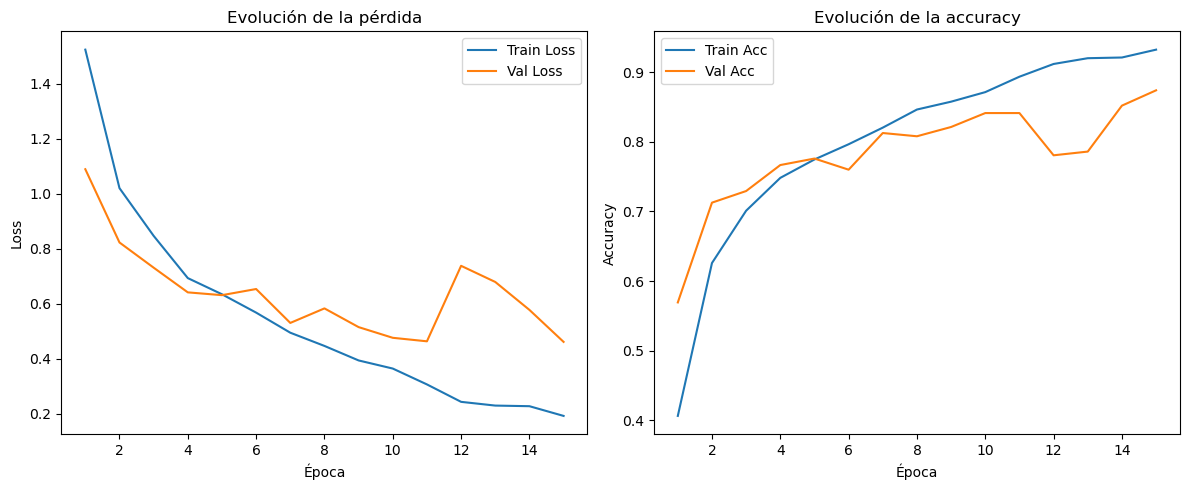

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.title("Evolución de la accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluación final en test
El conjunto de test se usa aquí al final del baseline, no durante cada época.
Eso es correcto metodológicamente.

In [ ]:
test_loss, test_acc, y_true, y_pred = evaluate(
    baseline_model,
    dataloaders["test"],
    criterion,
    DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4532
Test Accuracy: 0.8734


## Matriz de confusión
La matriz de confusión es esencial para ver:

- qué clases confunde más,
- y si el modelo aprende mejor unas que otras.

In [2]:
cm = confusion_matrix(y_true, y_pred)
classes = loader_info["classes"]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Matriz de confusión - CNN baseline")
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
# Format the values in the confusion matrix as float with 2 decimals if normalized, otherwise as integers
fmt = '.2f' if normalize else 'd'
# Determine a threshold to change text color for better readability
thresh = cm.max() / 2.
# Iterate through each cell in the confusion matrix
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    # Place the text in the middle of each cell
    plt.text(j, i, format(cm[i, j], fmt),
              horizontalalignment="center",
              color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

NameError: name 'confusion_matrix' is not defined

## Classification report
Aquí se avanza allá de la accuracy:

- precision
- recall
- F1 por clase

In [ ]:
report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
AnnualCrop,0.865385,0.900000,0.882353,150.000000
Forest,0.907285,0.913333,0.910299,150.000000
HerbaceousVegetation,0.821429,0.766667,0.793103,150.000000
Highway,0.858209,0.766667,0.809859,150.000000
Industrial,0.935484,0.966667,0.950820,150.000000
Pasture,0.899281,0.833333,0.865052,150.000000
PermanentCrop,0.787500,0.834437,0.810289,151.000000
Residential,0.918750,0.980000,0.948387,150.000000
River,0.805369,0.800000,0.802676,150.000000
SeaLake,0.929936,0.973333,0.951140,150.000000


## Guardando métricas básicas
Dejando organizado el resultado principal del baseline para compararlo con el bloque 2

In [ ]:
metrics_baseline = {
    "model": "CNN_desde_cero_baseline",
    "train_acc_final": history["train_acc"][-1],
    "val_acc_final": history["val_acc"][-1],
    "test_acc": test_acc,
    "test_loss": test_loss
}

metrics_baseline

{'model': 'CNN_desde_cero_baseline',
 'train_acc_final': 0.9324189169881412,
 'val_acc_final': 0.874,
 'test_acc': 0.8734177215189873,
 'test_loss': 0.45321442948270846}

## Observaciones iniciales del baseline

- Se ha entrenado una CNN desde cero con 4 bloques convolucionales y filtros progresivos 32-64-128-256.
- Se ha utilizado `CrossEntropyLoss` como función de pérdida y `Adam` como optimizador.
- El entrenamiento se ha monitorizado mediante curvas de pérdida y accuracy en entrenamiento y validación.
- La evaluación final se ha realizado sobre el conjunto de test, utilizando accuracy, matriz de confusión y métricas por clase.
- Este modelo servirá como baseline para comparar posteriormente con versiones mejoradas y con modelos preentrenados.

# CNN mejorada con Batch Normalization

En esta sección se construye una versión mejorada de la CNN baseline incorporando capas de Batch Normalization después de cada convolución.

Objetivos:
- evaluar si Batch Normalization estabiliza el entrenamiento,
- comprobar si mejora la accuracy en validación y test,
- comparar los resultados con la CNN baseline.

## Definiendo la CNN mejorada con BatchNorm
El patrón más habitual es:

Conv → BatchNorm → ReLU → Pool

porque:

- la convolución genera activaciones,
- BatchNorm las estabiliza,
- ReLU aplica no linealidad,
- y después se reduce dimensionalidad con pooling.

In [ ]:
class EuroSATCNNBatchNorm(nn.Module):
    def __init__(self, num_classes: int = 10, dropout_p: float = 0.3):
        super().__init__()

        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), #agregado en cada bloque
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Bloque 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Bloque 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Bloque 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Instanciando el nuevo modelo

In [ ]:
bn_model = EuroSATCNNBatchNorm(num_classes=num_classes, dropout_p=0.3).to(DEVICE)
print(bn_model)

EuroSATCNNBatchNorm(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_s

## Redefiniendo la función de pérdida y optimizador

In [ ]:
criterion_bn = nn.CrossEntropyLoss()
optimizer_bn = optim.Adam(bn_model.parameters(), lr=1e-3)

## Entrenando el modelo con Batch Normalization

Se entrena la versión mejorada manteniendo el mismo número de épocas, optimizador y función de pérdida que en la CNN baseline, de forma que la comparación entre ambas arquitecturas sea lo más justa posible.

In [ ]:
bn_model_trained, history_bn = train_model(
    model=bn_model,
    dataloaders=dataloaders,
    criterion=criterion_bn,
    optimizer=optimizer_bn,
    device=DEVICE,
    num_epochs=15
)

Epoch [1/15] Train Loss: 1.2800 | Train Acc: 0.5482 | Val Loss: 0.8334 | Val Acc: 0.6880
Epoch [2/15] Train Loss: 0.8624 | Train Acc: 0.6911 | Val Loss: 1.0105 | Val Acc: 0.6540
Epoch [3/15] Train Loss: 0.7380 | Train Acc: 0.7377 | Val Loss: 0.6433 | Val Acc: 0.7673
Epoch [4/15] Train Loss: 0.6983 | Train Acc: 0.7617 | Val Loss: 0.7684 | Val Acc: 0.7353
Epoch [5/15] Train Loss: 0.6307 | Train Acc: 0.7807 | Val Loss: 0.7262 | Val Acc: 0.7513
Epoch [6/15] Train Loss: 0.5567 | Train Acc: 0.8058 | Val Loss: 0.5351 | Val Acc: 0.8153
Epoch [7/15] Train Loss: 0.4999 | Train Acc: 0.8267 | Val Loss: 0.8596 | Val Acc: 0.7573
Epoch [8/15] Train Loss: 0.4820 | Train Acc: 0.8305 | Val Loss: 0.5493 | Val Acc: 0.7973
Epoch [9/15] Train Loss: 0.4370 | Train Acc: 0.8550 | Val Loss: 0.5001 | Val Acc: 0.8260
Epoch [10/15] Train Loss: 0.4141 | Train Acc: 0.8577 | Val Loss: 0.4933 | Val Acc: 0.8160
Epoch [11/15] Train Loss: 0.4014 | Train Acc: 0.8633 | Val Loss: 0.4896 | Val Acc: 0.8407
Epoch [12/15] Train

## Curvas de entrenamiento del modelo mejorado

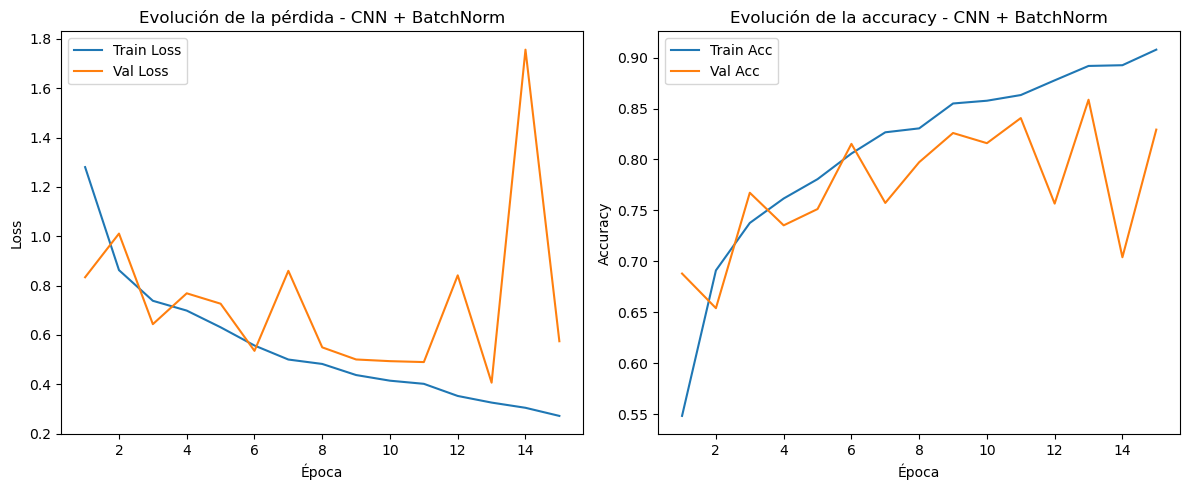

In [ ]:
epochs_bn = range(1, len(history_bn["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_bn, history_bn["train_loss"], label="Train Loss")
plt.plot(epochs_bn, history_bn["val_loss"], label="Val Loss")
plt.title("Evolución de la pérdida - CNN + BatchNorm")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_bn, history_bn["train_acc"], label="Train Acc")
plt.plot(epochs_bn, history_bn["val_acc"], label="Val Acc")
plt.title("Evolución de la accuracy - CNN + BatchNorm")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluación en test del modelo mejorado

In [ ]:
test_loss_bn, test_acc_bn, y_true_bn, y_pred_bn = evaluate(
    bn_model_trained,
    dataloaders["test"],
    criterion_bn,
    DEVICE
)

print(f"Test Loss (BatchNorm): {test_loss_bn:.4f}")
print(f"Test Accuracy (BatchNorm): {test_acc_bn:.4f}")

Test Loss (BatchNorm): 0.4364
Test Accuracy (BatchNorm): 0.8494


## Matriz de confusión del modelo mejorado

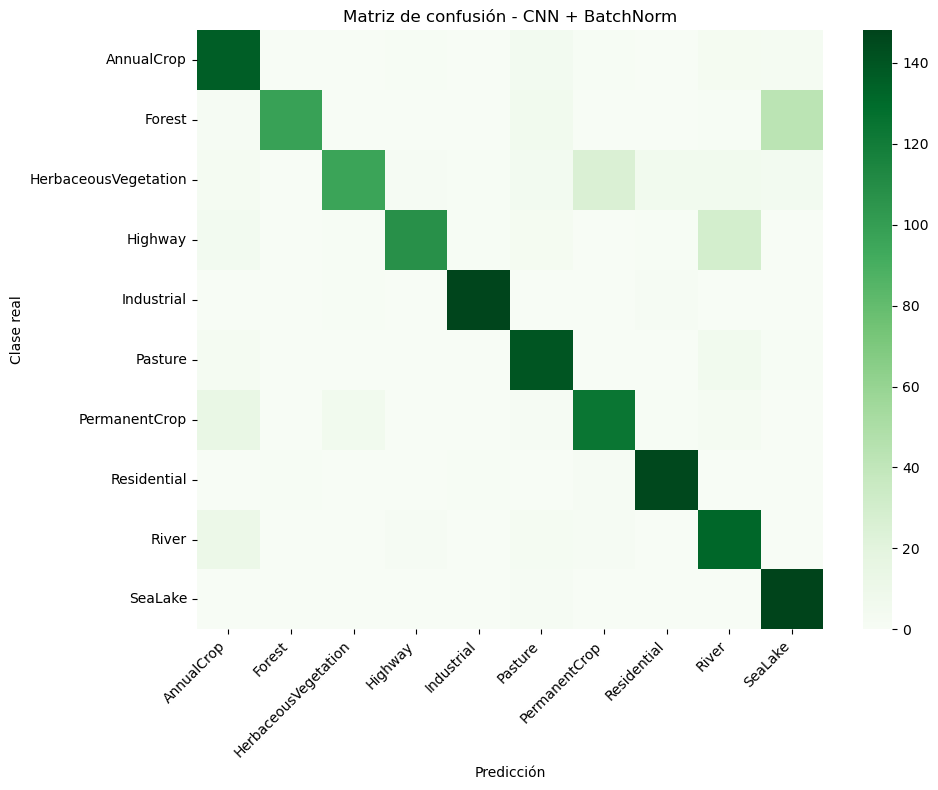

In [ ]:
cm_bn = confusion_matrix(y_true_bn, y_pred_bn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_bn, annot=False, cmap="Greens", xticklabels=classes, yticklabels=classes)
plt.title("Matriz de confusión - CNN + BatchNorm")
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Classification report del modelo mejorado

In [ ]:
report_bn = classification_report(y_true_bn, y_pred_bn, target_names=classes, output_dict=True)
df_report_bn = pd.DataFrame(report_bn).transpose()
df_report_bn

,precision,recall,f1-score,support
AnnualCrop,0.777143,0.906667,0.836923,150.000000
Forest,0.989899,0.653333,0.787149,150.000000
HerbaceousVegetation,0.923077,0.640000,0.755906,150.000000
Highway,0.955752,0.720000,0.821293,150.000000
Industrial,0.980000,0.980000,0.980000,150.000000
Pasture,0.838323,0.933333,0.883281,150.000000
PermanentCrop,0.800000,0.821192,0.810458,151.000000
Residential,0.935897,0.973333,0.954248,150.000000
River,0.725275,0.880000,0.795181,150.000000
SeaLake,0.740000,0.986667,0.845714,150.000000


## Guardando las métricas básicas del modelo mejorado

In [ ]:
metrics_batchnorm = {
    "model": "CNN_desde_cero_batchnorm",
    "train_acc_final": history_bn["train_acc"][-1],
    "val_acc_final": history_bn["val_acc"][-1],
    "test_acc": test_acc_bn,
    "test_loss": test_loss_bn
}

metrics_batchnorm

{'model': 'CNN_desde_cero_batchnorm',
 'train_acc_final': 0.9078439777111016,
 'val_acc_final': 0.8293333333333334,
 'test_acc': 0.8494337108594271,
 'test_loss': 0.43640436910137503}

## Comparación entre la CNN baseline y la CNN con Batch Normalization

In [ ]:
df_compare = pd.DataFrame([
    metrics_baseline,
    metrics_batchnorm
])

df_compare

,model,train_acc_final,val_acc_final,test_acc,test_loss
0,CNN_desde_cero_baseline,0.932419,0.874000,0.873418,0.453214
1,CNN_desde_cero_batchnorm,0.907844,0.829333,0.849434,0.436404


## Gráfico comparativo de accuracies

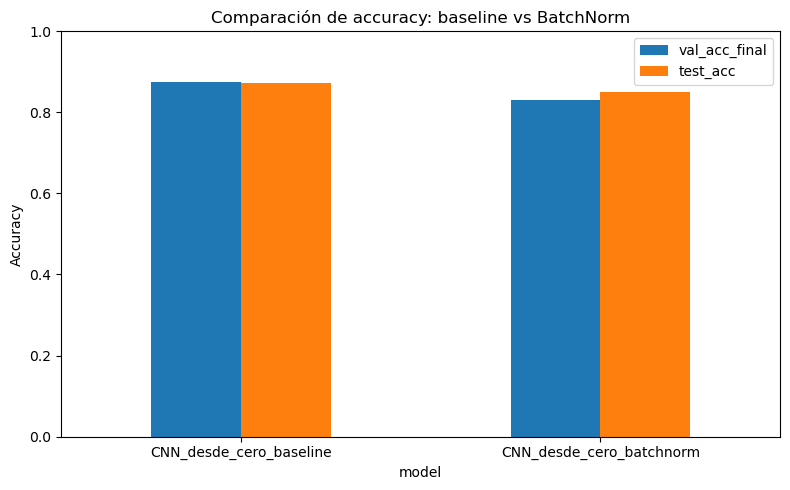

In [ ]:
compare_plot = df_compare[["model", "val_acc_final", "test_acc"]].copy()
compare_plot = compare_plot.set_index("model")

compare_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Comparación de accuracy: baseline vs BatchNorm")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Observaciones iniciales de la mejora con Batch Normalization

- Se ha construido una variante de la CNN baseline incorporando Batch Normalization después de cada capa convolucional.
- El resto de condiciones experimentales se han mantenido constantes para asegurar una comparación justa con el baseline.
- La comparación final se realizará atendiendo a las métricas de validación y test, así como al comportamiento de las curvas de entrenamiento y la matriz de confusión.

# CNN baseline con Data Augmentation

En esta sección se entrena la misma arquitectura baseline de la CNN desde cero, pero activando técnicas de data augmentation en el conjunto de entrenamiento.

Objetivos:
- evaluar si el aumento de datos mejora la generalización,
- comprobar su impacto en validación y test,
- comparar los resultados con la CNN baseline y con la versión con Batch Normalization.

## Crear nuevos dataloaders con augmentation
Usamos la misma función que en el baseline, pero ahora con: use_augmentation=True.

Eso significa que en el conjunto de entrenamiento se aplicarán transformaciones aleatorias.

In [ ]:
dataloaders_aug, loader_info_aug = create_dataloaders_from_splits(
    split_info=split_info,
    data_dir=DATA_DIR,
    image_size=64,
    batch_size=32,
    num_workers=0,
    use_augmentation=True,
    normalize_with_imagenet=False
)

loader_info_aug

{'classes': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_to_idx': {'AnnualCrop': 0,
  'Forest': 1,
  'HerbaceousVegetation': 2,
  'Highway': 3,
  'Industrial': 4,
  'Pasture': 5,
  'PermanentCrop': 6,
  'Residential': 7,
  'River': 8,
  'SeaLake': 9},
 'image_size': 64,
 'batch_size': 32,
 'num_workers': 0,
 'use_augmentation': True,
 'normalize_with_imagenet': False,
 'n_train': 6999,
 'n_val': 1500,
 'n_test': 1501}

## Visualización de ejemplos con data augmentation
Se muestra visualmente que:

- las imágenes se transforman,
- pero siguen siendo reconocibles,
- y eso ayuda a aumentar variabilidad en entrenamiento.

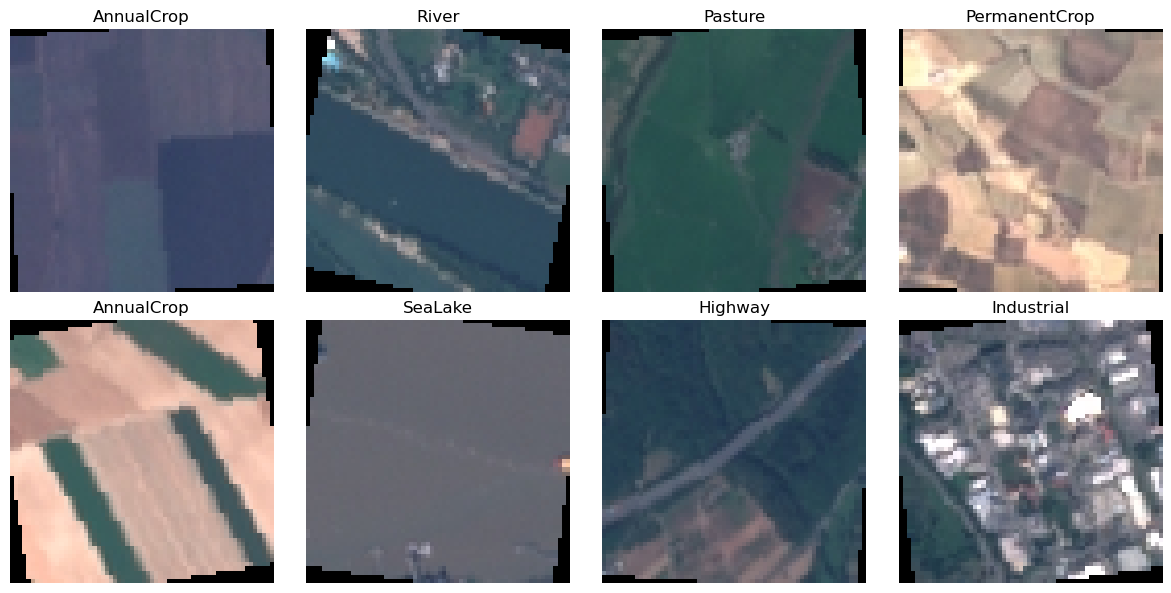

In [ ]:
images_aug, labels_aug = next(iter(dataloaders_aug["train"]))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = images_aug[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    img = img.clip(0, 1)

    axes[i].imshow(img)
    axes[i].set_title(loader_info_aug["classes"][labels_aug[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Definir el modelo baseline para augmentation
Porque queremos responder a esta pregunta:

¿La misma CNN baseline mejora si entrenamos con data augmentation?

No queremos mezclar aquí BatchNorm + augmentation todavía, porque complicaría la comparación.

In [ ]:
aug_model = EuroSATBaselineCNN(num_classes=num_classes, dropout_p=0.3).to(DEVICE)
print(aug_model)

EuroSATBaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=Tru

## Definir pérdida y optimizador

In [ ]:
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.Adam(aug_model.parameters(), lr=1e-3)

## Entrenamiento del baseline con data augmentation
Qué esperamos aquí. Dos posibilidades razonables:

- Posibilidad A: Mejora algo la validación y test.

- Posibilidad B: La accuracy de train baja un poco, pero validación/test mejoran o se estabilizan. Eso sería normal, porque augmentation suele dificultar algo el train, pero puede ayudar a generalizar.

In [ ]:
aug_model_trained, history_aug = train_model(
    model=aug_model,
    dataloaders=dataloaders_aug,
    criterion=criterion_aug,
    optimizer=optimizer_aug,
    device=DEVICE,
    num_epochs=15
)

Epoch [1/15] Train Loss: 1.5447 | Train Acc: 0.4046 | Val Loss: 1.1414 | Val Acc: 0.5773
Epoch [2/15] Train Loss: 1.0627 | Train Acc: 0.6017 | Val Loss: 0.8708 | Val Acc: 0.6760
Epoch [3/15] Train Loss: 0.8952 | Train Acc: 0.6825 | Val Loss: 0.8531 | Val Acc: 0.7113
Epoch [4/15] Train Loss: 0.7586 | Train Acc: 0.7298 | Val Loss: 0.6322 | Val Acc: 0.7827
Epoch [5/15] Train Loss: 0.7035 | Train Acc: 0.7448 | Val Loss: 0.6211 | Val Acc: 0.7787
Epoch [6/15] Train Loss: 0.6314 | Train Acc: 0.7703 | Val Loss: 0.5630 | Val Acc: 0.7980
Epoch [7/15] Train Loss: 0.5757 | Train Acc: 0.7983 | Val Loss: 0.5118 | Val Acc: 0.8127
Epoch [8/15] Train Loss: 0.5290 | Train Acc: 0.8120 | Val Loss: 0.5400 | Val Acc: 0.7967
Epoch [9/15] Train Loss: 0.4823 | Train Acc: 0.8341 | Val Loss: 0.5163 | Val Acc: 0.8233
Epoch [10/15] Train Loss: 0.4556 | Train Acc: 0.8364 | Val Loss: 0.4327 | Val Acc: 0.8587
Epoch [11/15] Train Loss: 0.4138 | Train Acc: 0.8563 | Val Loss: 0.3846 | Val Acc: 0.8673
Epoch [12/15] Train

## Curvas del modelo con augmentation

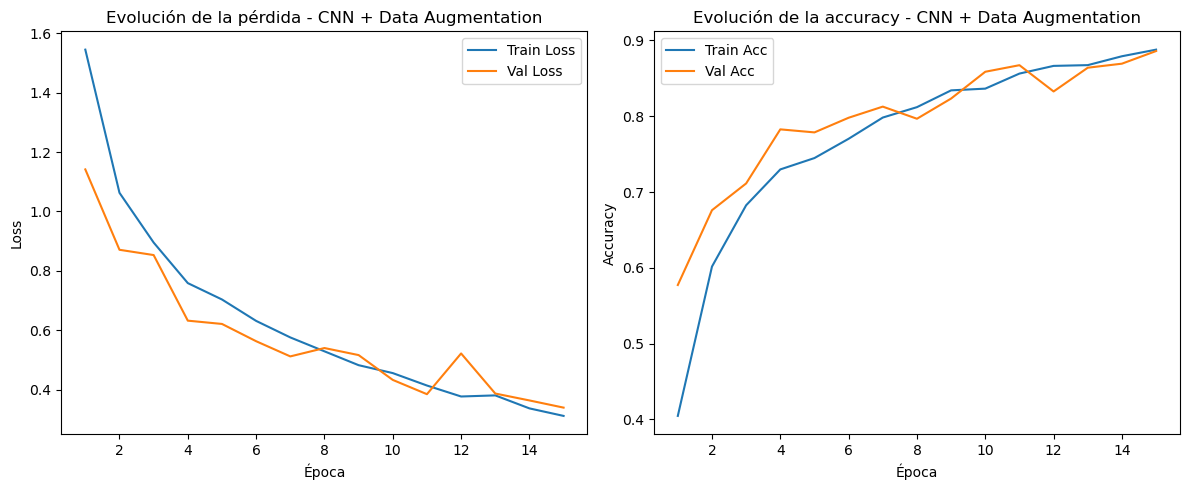

In [ ]:
epochs_aug = range(1, len(history_aug["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_aug, history_aug["train_loss"], label="Train Loss")
plt.plot(epochs_aug, history_aug["val_loss"], label="Val Loss")
plt.title("Evolución de la pérdida - CNN + Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_aug, history_aug["train_acc"], label="Train Acc")
plt.plot(epochs_aug, history_aug["val_acc"], label="Val Acc")
plt.title("Evolución de la accuracy - CNN + Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluación en test

In [ ]:
test_loss_aug, test_acc_aug, y_true_aug, y_pred_aug = evaluate(
    aug_model_trained,
    dataloaders_aug["test"],
    criterion_aug,
    DEVICE
)

print(f"Test Loss (Augmentation): {test_loss_aug:.4f}")
print(f"Test Accuracy (Augmentation): {test_acc_aug:.4f}")

Test Loss (Augmentation): 0.3573
Test Accuracy (Augmentation): 0.8794


## Matriz de confusión

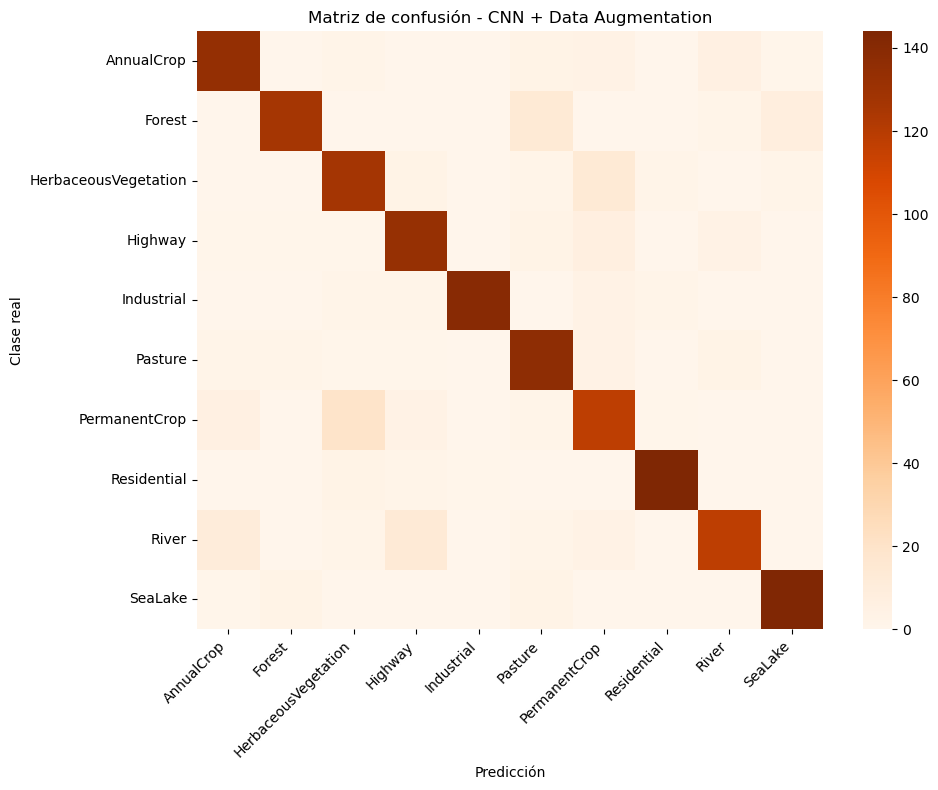

In [ ]:
cm_aug = confusion_matrix(y_true_aug, y_pred_aug)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_aug, annot=False, cmap="Oranges", xticklabels=classes, yticklabels=classes)
plt.title("Matriz de confusión - CNN + Data Augmentation")
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Classification report

In [ ]:
report_aug = classification_report(y_true_aug, y_pred_aug, target_names=classes, output_dict=True)
df_report_aug = pd.DataFrame(report_aug).transpose()
df_report_aug

,precision,recall,f1-score,support
AnnualCrop,0.864516,0.893333,0.878689,150.000000
Forest,0.954545,0.840000,0.893617,150.000000
HerbaceousVegetation,0.803797,0.846667,0.824675,150.000000
Highway,0.841772,0.886667,0.863636,150.000000
Industrial,0.992908,0.933333,0.962199,150.000000
Pasture,0.825301,0.913333,0.867089,150.000000
PermanentCrop,0.761290,0.781457,0.771242,151.000000
Residential,0.966443,0.960000,0.963211,150.000000
River,0.887218,0.786667,0.833922,150.000000
SeaLake,0.928571,0.953333,0.940789,150.000000


## Análisis de errores: imágenes mal clasificadas

A continuación se muestran algunos ejemplos en los que la mejor variante de CNN desde cero (entrenada con data augmentation) cometió errores de clasificación. Este análisis permite complementar la matriz de confusión y el classification report, ayudando a identificar confusiones entre clases visualmente similares del dataset EuroSAT.

Número total de imágenes mal clasificadas: 181


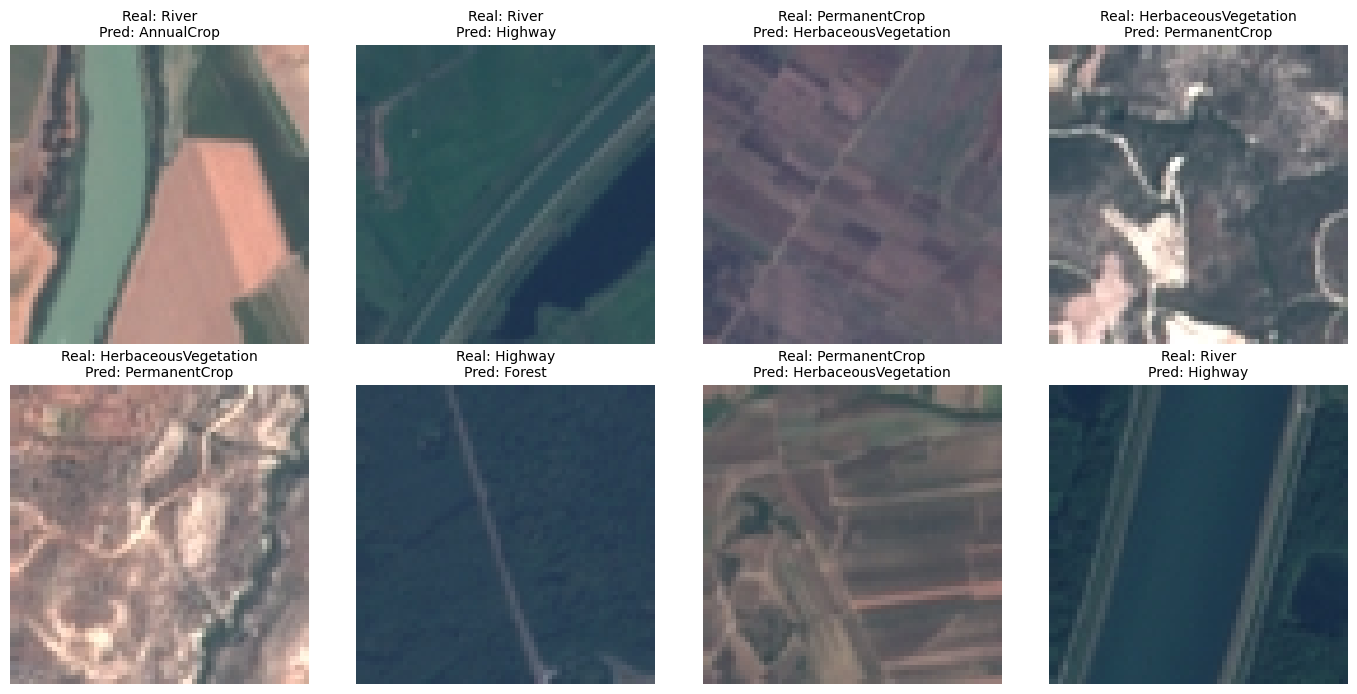

In [ ]:
# Obtener el dataset de test usado en la variante con augmentation
test_dataset_aug = dataloaders_aug["test"].dataset

# Buscar índices mal clasificados
misclassified_indices = [i for i, (yt, yp) in enumerate(zip(y_true_aug, y_pred_aug)) if yt != yp]

print(f"Número total de imágenes mal clasificadas: {len(misclassified_indices)}")

# Mostrar unas pocas imágenes mal clasificadas
n_examples = min(8, len(misclassified_indices))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for plot_idx in range(8):
    axes[plot_idx].axis("off")

for plot_idx, mis_idx in enumerate(misclassified_indices[:n_examples]):
    img_tensor, true_label = test_dataset_aug[mis_idx]

    # Desnormalizar para visualizar (mean=std=0.5)
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    img = img.clip(0, 1)

    pred_label = y_pred_aug[mis_idx]

    axes[plot_idx].imshow(img)
    axes[plot_idx].set_title(
        f"Real: {classes[true_label]}\nPred: {classes[pred_label]}",
        fontsize=10
    )
    axes[plot_idx].axis("off")

plt.tight_layout()
plt.show()

### Observación preliminar

Los errores mostrados confirman que las confusiones del modelo se concentran principalmente en clases con alta similitud visual, especialmente entre cubiertas vegetales (`PermanentCrop`, `HerbaceousVegetation`) y entre estructuras lineales o alargadas del terreno, como `River` y `Highway`. Esto es coherente con lo observado previamente en la matriz de confusión y en las métricas por clase.

## Guardar métricas del modelo con augmentation

In [ ]:
metrics_augmentation = {
    "model": "CNN_desde_cero_augmentation",
    "train_acc_final": history_aug["train_acc"][-1],
    "val_acc_final": history_aug["val_acc"][-1],
    "test_acc": test_acc_aug,
    "test_loss": test_loss_aug
}

metrics_augmentation

{'model': 'CNN_desde_cero_augmentation',
 'train_acc_final': 0.8878411201600228,
 'val_acc_final': 0.886,
 'test_acc': 0.8794137241838774,
 'test_loss': 0.35731451923175306}

# Comparación global de las variantes de CNN desde cero

In [ ]:
df_compare_all = pd.DataFrame([
    metrics_baseline,
    metrics_batchnorm,
    metrics_augmentation
])

df_compare_all

,model,train_acc_final,val_acc_final,test_acc,test_loss
0,CNN_desde_cero_baseline,0.932419,0.874000,0.873418,0.453214
1,CNN_desde_cero_batchnorm,0.907844,0.829333,0.849434,0.436404
2,CNN_desde_cero_augmentation,0.887841,0.886000,0.879414,0.357315


## Gráfico comparativo global

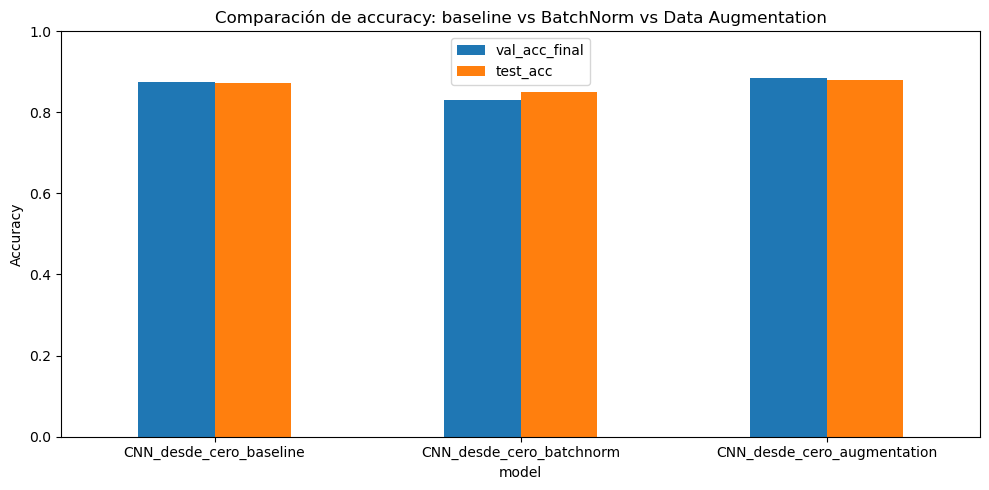

In [ ]:
compare_all_plot = df_compare_all[["model", "val_acc_final", "test_acc"]].copy()
compare_all_plot = compare_all_plot.set_index("model")

compare_all_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Comparación de accuracy: baseline vs BatchNorm vs Data Augmentation")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Observaciones iniciales del modelo con Data Augmentation

- Se ha mantenido la misma arquitectura baseline de la CNN desde cero.
- La única modificación experimental ha sido la incorporación de data augmentation en el conjunto de entrenamiento.
- Esto permite evaluar de forma aislada si el aumento de datos mejora la capacidad de generalización del modelo.
- La comparación se realizará usando accuracy en validación y test, además de matriz de confusión y métricas por clase.

# Conclusiones finales de las variantes de CNN desde cero

En este bloque se han comparado tres variantes de una CNN diseñada desde cero para la clasificación de imágenes del dataset EuroSAT: una versión baseline, una versión con Batch Normalization y una versión con Data Augmentation.

La CNN baseline ya mostró un rendimiento sólido, alcanzando una accuracy de validación de 0.8740 y una accuracy de test de 0.8734, lo que indica que la arquitectura seleccionada era adecuada para el problema.

La incorporación de Batch Normalization no mejoró los resultados del baseline bajo las condiciones experimentales utilizadas. Aunque el modelo siguió mostrando un rendimiento correcto, obtuvo peores métricas de validación y test, además de una mayor oscilación en las curvas de validación. Por tanto, en este caso Batch Normalization no aportó una mejora clara de estabilidad ni de generalización.

La mejor variante fue la CNN con Data Augmentation. Esta alcanzó la mejor accuracy de validación (0.8860), la mejor accuracy de test (0.8794) y la menor pérdida en test (0.3573). Esto sugiere que el aumento de datos ayudó a mejorar la capacidad de generalización del modelo, haciendo el entrenamiento algo más exigente pero produciendo un comportamiento final más robusto.

En consecuencia, dentro de las variantes de CNN desde cero analizadas, el modelo con Data Augmentation se considera la mejor alternativa y será la referencia principal para compararlo posteriormente con los modelos preentrenados.

## Resultados obtenidos
Guarda los resultados para el posterior analisis

In [ ]:
metrics_baseline = {
    "model": "CNN_desde_cero_baseline",
    "train_acc_final": 0.932419,
    "val_acc_final": 0.874000,
    "test_acc": 0.873418,
    "test_loss": 0.453214
}

metrics_batchnorm = {
    "model": "CNN_desde_cero_batchnorm",
    "train_acc_final": 0.907844,
    "val_acc_final": 0.829333,
    "test_acc": 0.849434,
    "test_loss": 0.436404
}

metrics_augmentation = {
    "model": "CNN_desde_cero_augmentation",
    "train_acc_final": 0.887841,
    "val_acc_final": 0.886000,
    "test_acc": 0.879414,
    "test_loss": 0.357315
}

# Prueba final con el dataset completo

Tras validar la pipeline experimental sobre un subconjunto balanceado de 1000 imágenes por clase, se realiza una prueba final sobre el dataset completo de EuroSAT.

Para esta prueba se utiliza la mejor variante de CNN desde cero obtenida en el análisis anterior: la CNN baseline entrenada con data augmentation.

## Creando el splits del dataset completo

In [ ]:
full_split_info = create_full_dataset_splits(
    data_dir=DATA_DIR,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    seed=SEED
)

print("Train:", full_split_info["n_train"])
print("Validation:", full_split_info["n_val"])
print("Test:", full_split_info["n_test"])

Train: 18899
Validation: 4050
Test: 4051


## Creando el dataloaders del dataset completo con augmentation

In [ ]:
dataloaders_full_aug, loader_info_full_aug = create_dataloaders_from_splits(
    split_info=full_split_info,
    data_dir=DATA_DIR,
    image_size=64,
    batch_size=32,
    num_workers=0,
    use_augmentation=True,
    normalize_with_imagenet=False
)

loader_info_full_aug

{'classes': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_to_idx': {'AnnualCrop': 0,
  'Forest': 1,
  'HerbaceousVegetation': 2,
  'Highway': 3,
  'Industrial': 4,
  'Pasture': 5,
  'PermanentCrop': 6,
  'Residential': 7,
  'River': 8,
  'SeaLake': 9},
 'image_size': 64,
 'batch_size': 32,
 'num_workers': 0,
 'use_augmentation': True,
 'normalize_with_imagenet': False,
 'n_train': 18899,
 'n_val': 4050,
 'n_test': 4051}

## Definiendo el modelo final

In [ ]:
full_aug_model = EuroSATBaselineCNN(num_classes=num_classes, dropout_p=0.3).to(DEVICE)

criterion_full_aug = nn.CrossEntropyLoss()
optimizer_full_aug = optim.Adam(full_aug_model.parameters(), lr=1e-3)

print(full_aug_model)

EuroSATBaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=Tru

## Entrenando el modelo completo

In [ ]:
full_aug_model_trained, history_full_aug = train_model(
    model=full_aug_model,
    dataloaders=dataloaders_full_aug,
    criterion=criterion_full_aug,
    optimizer=optimizer_full_aug,
    device=DEVICE,
    num_epochs=15
)

Epoch [1/15] Train Loss: 1.2258 | Train Acc: 0.5282 | Val Loss: 0.8417 | Val Acc: 0.7072
Epoch [2/15] Train Loss: 0.7298 | Train Acc: 0.7359 | Val Loss: 0.5498 | Val Acc: 0.8000
Epoch [3/15] Train Loss: 0.5981 | Train Acc: 0.7853 | Val Loss: 0.5527 | Val Acc: 0.8059
Epoch [4/15] Train Loss: 0.5166 | Train Acc: 0.8208 | Val Loss: 0.4244 | Val Acc: 0.8496
Epoch [5/15] Train Loss: 0.4508 | Train Acc: 0.8425 | Val Loss: 0.4862 | Val Acc: 0.8360
Epoch [6/15] Train Loss: 0.3933 | Train Acc: 0.8656 | Val Loss: 0.3379 | Val Acc: 0.8765
Epoch [7/15] Train Loss: 0.3573 | Train Acc: 0.8768 | Val Loss: 0.3298 | Val Acc: 0.8847
Epoch [8/15] Train Loss: 0.3122 | Train Acc: 0.8910 | Val Loss: 0.2862 | Val Acc: 0.9027
Epoch [9/15] Train Loss: 0.2764 | Train Acc: 0.9053 | Val Loss: 0.3098 | Val Acc: 0.8938
Epoch [10/15] Train Loss: 0.2604 | Train Acc: 0.9123 | Val Loss: 0.3015 | Val Acc: 0.8946
Epoch [11/15] Train Loss: 0.2578 | Train Acc: 0.9130 | Val Loss: 0.2885 | Val Acc: 0.9059
Epoch [12/15] Train

## Curvas del modelo final

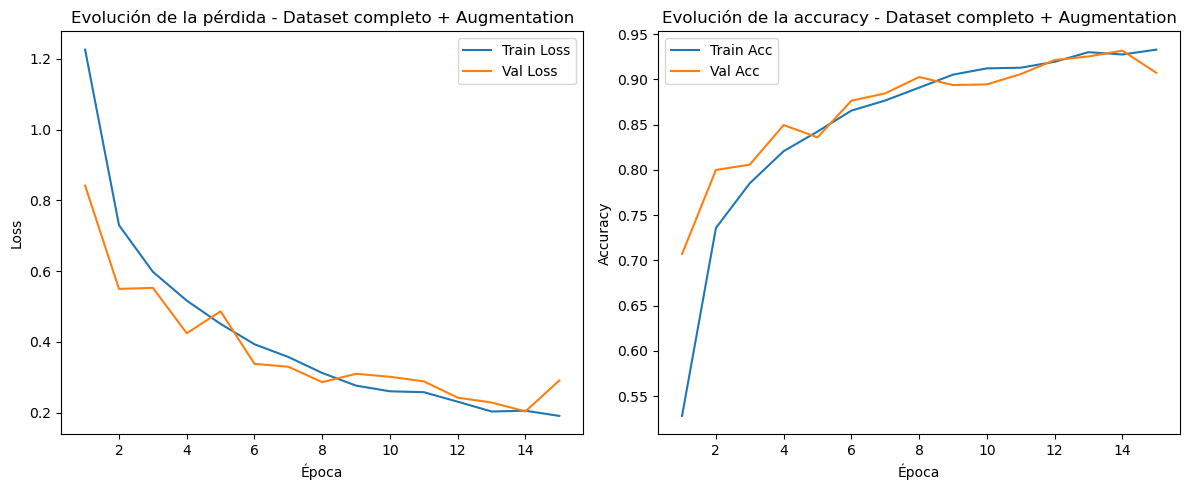

In [ ]:
epochs_full_aug = range(1, len(history_full_aug["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_full_aug, history_full_aug["train_loss"], label="Train Loss")
plt.plot(epochs_full_aug, history_full_aug["val_loss"], label="Val Loss")
plt.title("Evolución de la pérdida - Dataset completo + Augmentation")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_full_aug, history_full_aug["train_acc"], label="Train Acc")
plt.plot(epochs_full_aug, history_full_aug["val_acc"], label="Val Acc")
plt.title("Evolución de la accuracy - Dataset completo + Augmentation")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluación en test

In [ ]:
test_loss_full_aug, test_acc_full_aug, y_true_full_aug, y_pred_full_aug = evaluate(
    full_aug_model_trained,
    dataloaders_full_aug["test"],
    criterion_full_aug,
    DEVICE
)

print(f"Test Loss (Dataset completo + Augmentation): {test_loss_full_aug:.4f}")
print(f"Test Accuracy (Dataset completo + Augmentation): {test_acc_full_aug:.4f}")

Test Loss (Dataset completo + Augmentation): 0.2151
Test Accuracy (Dataset completo + Augmentation): 0.9319


## Guardar métricas

In [ ]:
metrics_full_augmentation = {
    "model": "CNN_full_dataset_augmentation",
    "train_acc_final": history_full_aug["train_acc"][-1],
    "val_acc_final": history_full_aug["val_acc"][-1],
    "test_acc": test_acc_full_aug,
    "test_loss": test_loss_full_aug
}

metrics_full_augmentation

{'model': 'CNN_full_dataset_augmentation',
 'train_acc_final': 0.9329594158421081,
 'val_acc_final': 0.9074074074074074,
 'test_acc': 0.9318686744013823,
 'test_loss': 0.21512539009787776}

## Comparación con la mejor CNN de 1000 por clase

In [ ]:
df_compare_size = pd.DataFrame([
    metrics_augmentation,
    metrics_full_augmentation
])

df_compare_size

,model,train_acc_final,val_acc_final,test_acc,test_loss
0,CNN_desde_cero_augmentation,0.887841,0.886000,0.879414,0.357315
1,CNN_full_dataset_augmentation,0.932959,0.907407,0.931869,0.215125


## Gráfico comparativo

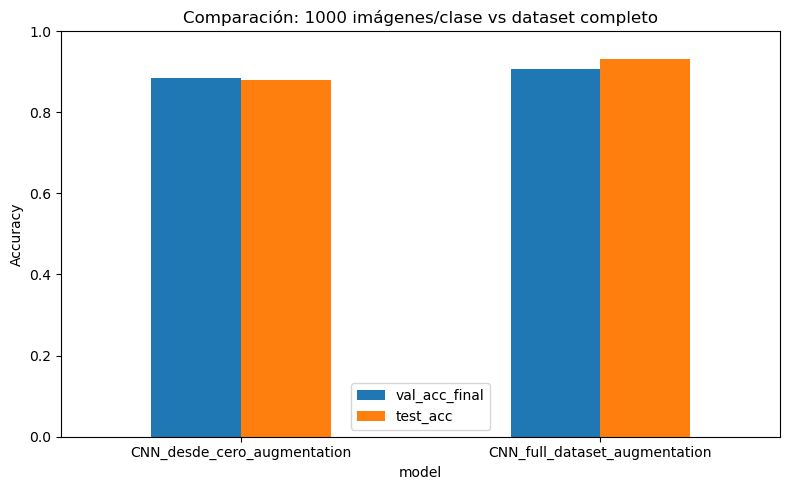

In [ ]:
compare_size_plot = df_compare_size[["model", "val_acc_final", "test_acc"]].copy()
compare_size_plot = compare_size_plot.set_index("model")

compare_size_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Comparación: 1000 imágenes/clase vs dataset completo")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Observación final

La prueba adicional con el dataset completo confirma que la mejor CNN desde cero obtenida sobre el subconjunto balanceado no solo mantiene su rendimiento, sino que lo mejora de forma clara al entrenarse con un mayor volumen de datos. En comparación con la versión entrenada con 1000 imágenes por clase, el modelo final con dataset completo y data augmentation alcanzó mejores métricas de validación y test, además de una pérdida final más baja.

Estos resultados indican que el subconjunto balanceado fue una estrategia adecuada para validar la pipeline experimental y comparar variantes de forma rápida y controlada. Sin embargo, una vez identificada la mejor configuración, el uso del dataset completo permitió explotar mejor la diversidad visual de EuroSAT y mejorar la capacidad de generalización del modelo.

En consecuencia, la mejor variante de CNN desde cero obtenida en este trabajo es la arquitectura baseline entrenada con data augmentation sobre el dataset completo.